In [1]:
import pandas as pd

# Load only Sheet1 from the Excel file
df = pd.read_excel("../data/energy_data.xlsx", sheet_name="Sheet1")
df.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


In [2]:
print("Shape:", df.shape)

# Data types and non-null counts
df.info()

# Summary statistics
df.describe()

Shape: (9568, 5)
<class 'pandas.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


,AT,V,AP,RH,PE
count,9568.000000,9568.000000,9568.000000,9568.000000,9568.000000
mean,19.651231,54.305804,1013.259078,73.308978,454.365009
std,7.452473,12.707893,5.938784,14.600269,17.066995
min,1.810000,25.360000,992.890000,25.560000,420.260000
25%,13.510000,41.740000,1009.100000,63.327500,439.750000
50%,20.345000,52.080000,1012.940000,74.975000,451.550000
75%,25.720000,66.540000,1017.260000,84.830000,468.430000
max,37.110000,81.560000,1033.300000,100.160000,495.760000


In [3]:
df.rename(columns={
    "AT": "AmbientTemp",
    "V": "ExhaustVacuum",
    "AP": "AmbientPressure",
    "RH": "RelativeHumidity",
    "PE": "PowerOutput"
}, inplace=True)

df.head()

,AmbientTemp,ExhaustVacuum,AmbientPressure,RelativeHumidity,PowerOutput
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


**Data Loading & Initial Inspection:**

Loaded Sheet1 of the Combined Cycle Power Plant dataset (9,568 rows × 5 columns) and checked for data quality.

*Findings:*  Fully numerical, no missing values, no anomalies — but features are on different scales, so we'll need to scale prior to modelling.


*Note:* Original column names (`AT`, `V`, `AP`, `RH`, `PE`) were abbreviations from the UCI dataset. Renaming them here for clarity throughout the notebook.

In [5]:
# EXPLORATORY DATA ANALYSIS

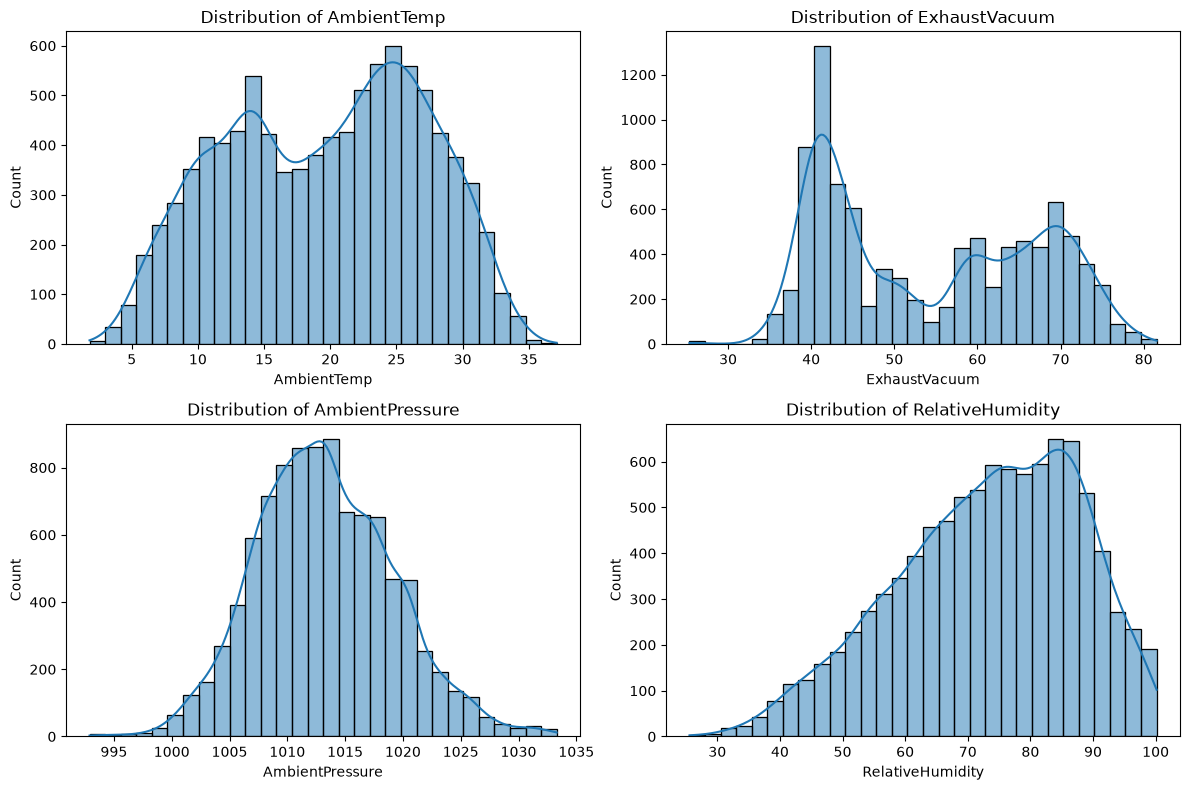

In [4]:
# 1. Column-wise distributions

import matplotlib.pyplot as plt
import seaborn as sns

predictors = ["AmbientTemp", "ExhaustVacuum", "AmbientPressure", "RelativeHumidity"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(predictors):
    sns.histplot(df[col], kde=True, bins=30, ax=axes[i], edgecolor='black')
    axes[i].set_title(f"Distribution of {col}")

plt.tight_layout()
plt.savefig("../images/01_predictor_distributions.png", dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:**

- `AmbientTemp` and `ExhaustVacuum` both show a **bimodal** distribution, likely reflecting seasonal operating conditions (e.g., summer vs. winter).
- `AmbientPressure` is roughly **normally distributed**, centered around 1013 mbar.
- `RelativeHumidity` is **left-skewed**, with most values concentrated between 60–90%.
- No extreme outliers or invalid values are visible — consistent with the earlier `.describe()` check.

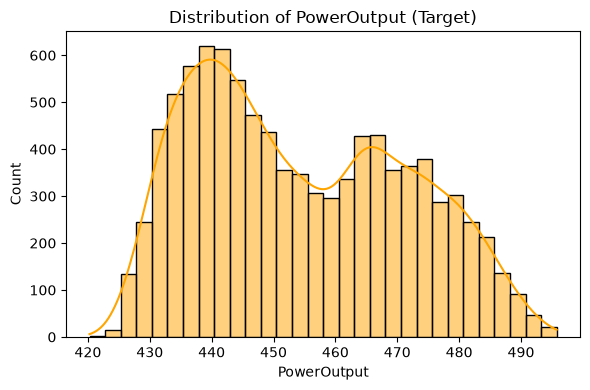

In [5]:
# Distribution of Target Column
plt.figure(figsize=(6, 4))
sns.histplot(df["PowerOutput"], kde=True, bins=30, edgecolor='black', color='orange')
plt.title("Distribution of PowerOutput (Target)")
plt.tight_layout()
plt.savefig("../images/02_target_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:**

- `PowerOutput` is also **bimodal**, mirroring the pattern seen in `AmbientTemp` and `ExhaustVacuum` — reinforcing that these two features likely drive most of the variation in the target.
- The distribution is reasonably well-behaved with no extreme outliers, so no transformation is needed before modeling.

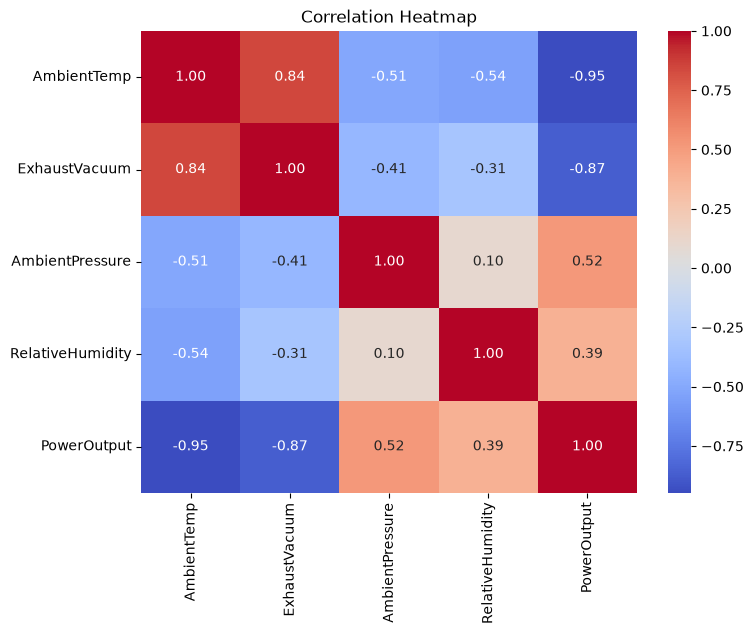

In [6]:
# Correlation Plot

plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.savefig("../images/03_correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:**

- `AmbientTemp` has the strongest relationship with `PowerOutput` (**-0.95**) — higher temperatures sharply reduce output.
- `ExhaustVacuum` is also strongly correlated with `PowerOutput` (**-0.87**) and with `AmbientTemp` (**0.84**) — this signals **multicollinearity**, which we'll address by testing Regression models.
- `AmbientPressure` and `RelativeHumidity` show weaker correlations with `PowerOutput` (**0.52**, **0.39**) and are nearly uncorrelated with each other (**0.10**).

`AmbientTemp` and `ExhaustVacuum` will likely dominate the model. Their mutual correlation is a good justification for testing regularized regression.

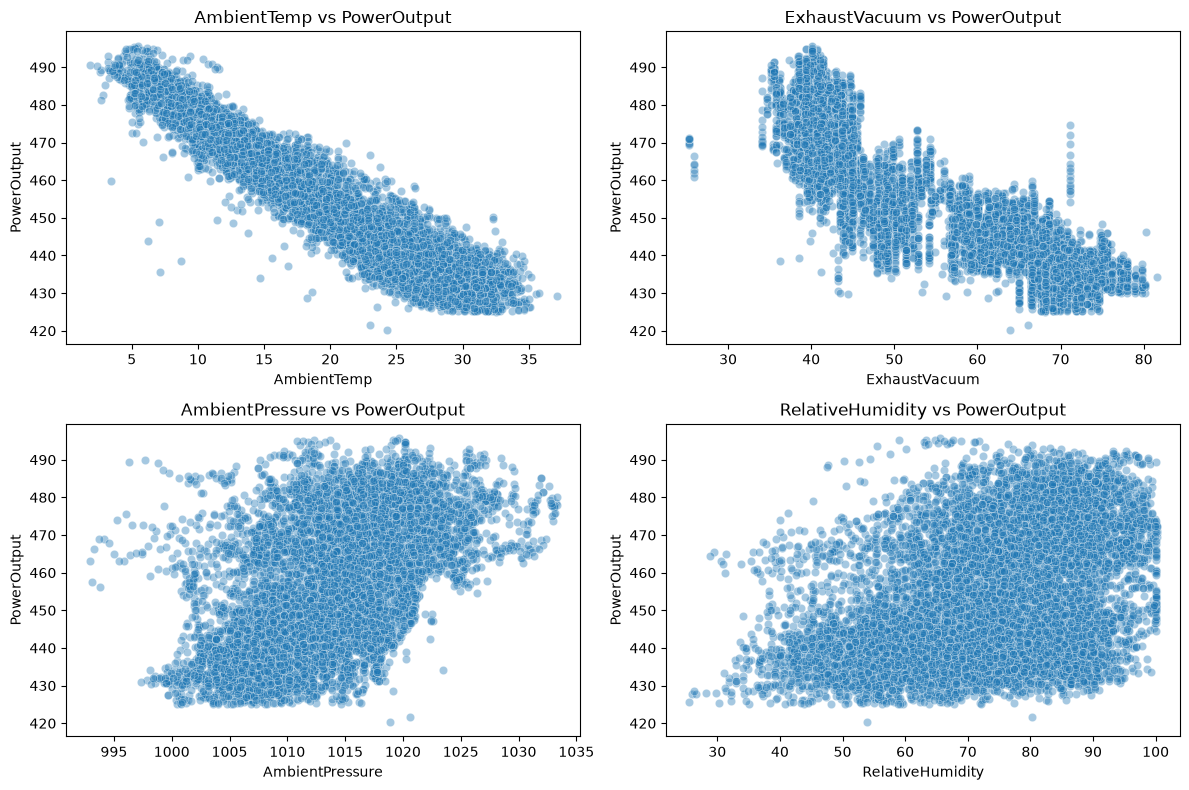

In [7]:
# 3. Scatter Plots

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(predictors):
    sns.scatterplot(x=df[col], y=df["PowerOutput"], ax=axes[i], alpha=0.4)
    axes[i].set_title(f"{col} vs PowerOutput")

plt.tight_layout()
plt.savefig("../images/04_scatter_plots.png", dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:**

- `AmbientTemp vs PowerOutput`: Strong, mostly linear negative relationship — matches the -0.95 correlation. A slight curve is visible at the low end, but linear regression should capture most of this well.
- `ExhaustVacuum vs PowerOutput`: Negative relationship, but with a distinct **clustered/step-like pattern** rather than a smooth line — likely reflecting the turbine's discrete operating modes. This is the clearest candidate for testing whether Polynomial Regression improves fit.
- `AmbientPressure vs PowerOutput`: Weak, diffuse positive relationship — matches the moderate 0.52 correlation. No clear linear or curved pattern; a lot of scatter/noise.
- `RelativeHumidity vs PowerOutput`: Similarly weak and diffuse (0.39 correlation) — wide spread with no strong shape.


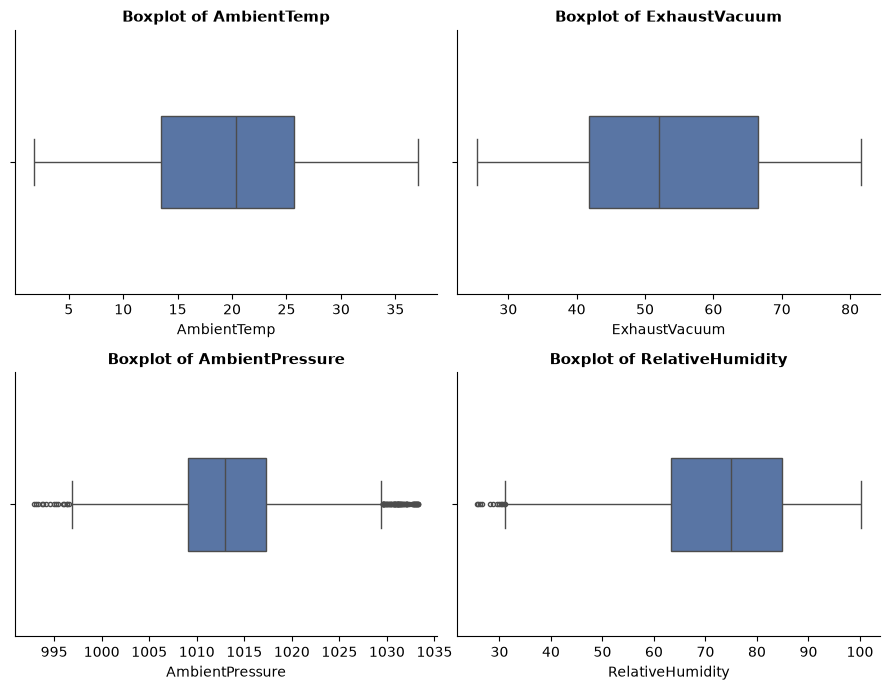

In [8]:
# 4. Outlier Detection using Boxplots

fig, axes = plt.subplots(2, 2, figsize=(9, 7))
axes = axes.flatten()

for i, col in enumerate(predictors):
    sns.boxplot(x=df[col], ax=axes[i], width=0.35, color='#4C72B0', fliersize=3)
    axes[i].set_title(f"Boxplot of {col}", fontsize=11, fontweight='bold')
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("../images/05_boxplots.png", dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:**

- `AmbientTemp` and `ExhaustVacuum`: No outliers — all points fall within the whiskers.
- `AmbientPressure`: A cluster of outliers on both tails — a few readings above ~1030 mbar and below ~997 mbar.
- `RelativeHumidity`: A small cluster of outliers on the low end, below ~30%.


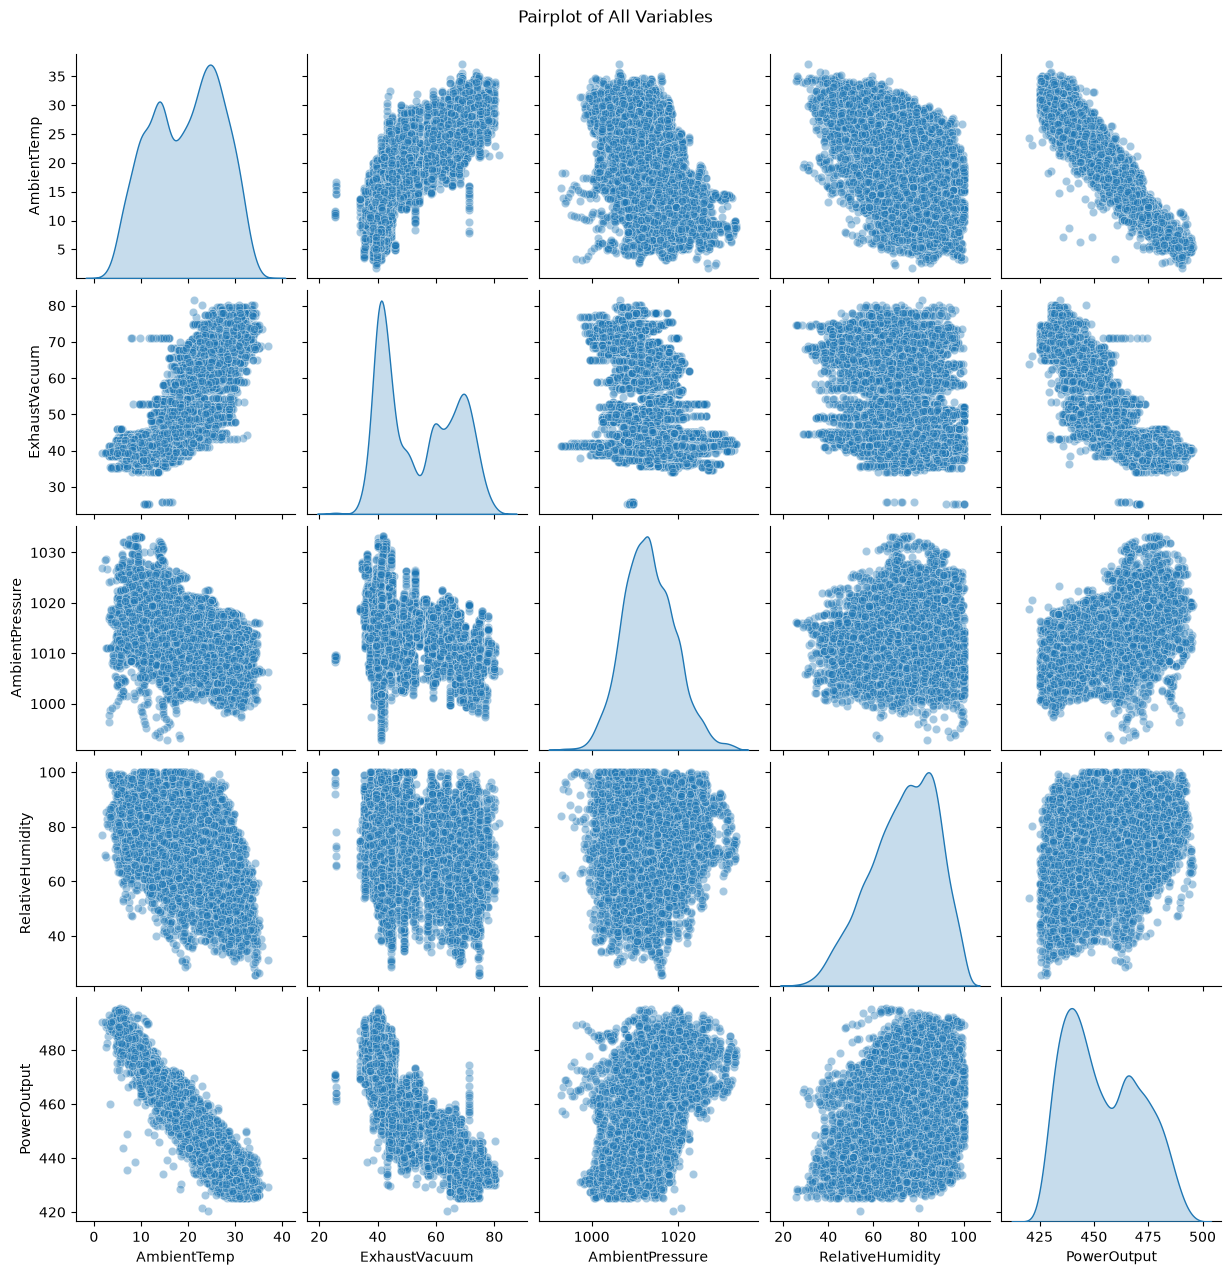

In [9]:
# PairPlots

sns.pairplot(df, diag_kind="kde", plot_kws={'alpha': 0.4})
plt.suptitle("Pairplot of All Variables", y=1.02)
plt.savefig("../images/06_pairplot.png", dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:**

- The pairplot confirms what we saw earlier: `AmbientTemp` and `ExhaustVacuum` show clear negative relationships with `PowerOutput`, while `AmbientPressure` and `RelativeHumidity` show weaker, more scattered relationships.
- `AmbientTemp` vs `ExhaustVacuum` shows a visible positive trend, confirming the multicollinearity flagged earlier in the heatmap.
- The diagonal KDE plots reiterate the bimodal shapes of `AmbientTemp`, `ExhaustVacuum`, and `PowerOutput`, and the near-normal/left-skewed shapes of `AmbientPressure` and `RelativeHumidity`.

The pairplot doesn't reveal anything new beyond our earlier individual plots, but it consolidates all relationships into a single reference view — useful for a quick visual summary of the dataset.